# 🏎️ Lights Out and Away We Go
## Racing to Intelligence with Azure AI and the Mercedes-AMG F1 Team

**Global Azure — Demo Notebook**

---

> *"In a sport where races are decided by tenths of a second and every decision is data-driven,  
> Formula 1 represents the ultimate stress test for modern enterprise systems."*  
> — Microsoft × Mercedes-AMG PETRONAS F1 Partnership Announcement, January 2026

---

### What we're building

An F1 car carries **400+ sensors** generating **1.1 million data points per second**.  
One of the most critical real-time decisions in a race: **when to pit for fresh tyres.**

In this notebook we will:
1. 📦 Load simulated F1 race telemetry data
2. 🔍 Explore and understand the data
3. 🤖 Train a machine learning model to predict pit stop recommendations
4. 🏁 Use the model to make a live race decision
5. ☁️ See how this maps to what Mercedes does with Azure ML at scale


---
## Step 0 — Install & Import Libraries

We're using:
- **pandas** — for data handling
- **scikit-learn** — for our ML model
- **matplotlib / seaborn** — for visualisation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# F1 colour palette
F1_RED    = '#E8002D'
F1_SILVER = '#6D6D6D'
F1_DARK   = '#1F1F27'
MERC_TEAL = '#00D2BE'
MERC_DARK = '#1B1B1B'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F8F8',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'sans-serif',
})

print('✅ Libraries loaded. Ready to race.')

✅ Libraries loaded. Ready to race.


---
## Step 1 — Load the Telemetry Data

Our dataset simulates race telemetry from **20 Grand Prix races**.  
Each row = one lap, from the perspective of one car.

| Column | Description |
|---|---|
| `race_id` | Race number (1–20) |
| `lap` | Lap number in the race |
| `tyre_compound` | soft / medium / hard |
| `tyre_age` | Number of laps on current set of tyres |
| `lap_time_delta` | Lap time vs a fresh tyre baseline (seconds, positive = slower) |
| `gap_to_car_behind` | Gap to car behind in seconds |
| `gap_to_car_ahead` | Gap to car ahead in seconds |
| `fuel_effect` | Time lost due to remaining fuel weight (seconds) |
| `safety_car` | 1 = safety car is deployed this lap |
| `pit_recommended` | 🎯 **Target: 1 = pit recommended, 0 = stay out** |

In [2]:
df = pd.read_csv('f1_telemetry.csv')

print(f'📊 Dataset shape: {df.shape[0]} laps × {df.shape[1]} columns')
print(f'🏁 Races covered: {df["race_id"].nunique()}')
print(f'🟢 Pit recommended: {df["pit_recommended"].sum()} laps ({df["pit_recommended"].mean()*100:.1f}%)')
print(f'🔴 Stay out:        {(df["pit_recommended"]==0).sum()} laps ({(df["pit_recommended"]==0).mean()*100:.1f}%)')
print()
df.head(10)

📊 Dataset shape: 885 laps × 10 columns
🏁 Races covered: 20
🟢 Pit recommended: 296 laps (33.4%)
🔴 Stay out:        589 laps (66.6%)



,race_id,lap,tyre_compound,tyre_age,lap_time_delta,gap_to_car_behind,gap_to_car_ahead,fuel_effect,safety_car,pit_recommended
0,1,1,hard,1,0.371,6.77,1.84,1.712,0,0
1,1,2,hard,2,0.464,5.03,3.79,1.691,0,0
2,1,3,hard,3,0.370,1.94,0.67,1.631,1,1
3,1,4,hard,4,0.468,3.79,0.45,1.640,0,0
4,1,5,hard,5,0.411,5.78,4.37,1.584,0,0
5,1,6,hard,6,0.443,0.83,1.12,1.569,0,0
6,1,7,hard,7,0.461,1.76,0.82,1.508,0,0
7,1,8,hard,8,0.423,12.97,0.73,1.500,0,0
8,1,9,hard,9,0.551,0.76,2.51,1.459,0,0
9,1,10,hard,10,0.579,6.83,6.05,1.430,0,0


---
## Step 2 — Explore the Data (EDA)

Before training anything, a good data scientist always asks:  
*"What does the data actually look like?"*

Let's look at the key signals a strategy engineer watches.

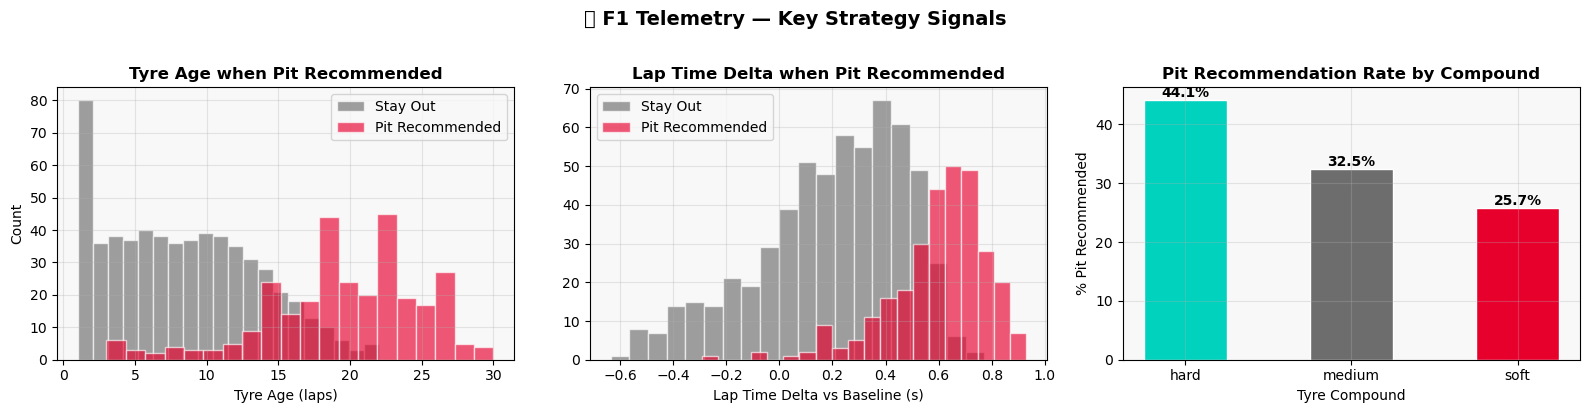

💡 Key insight: Soft tyres degrade fastest — highest pit recommendation rate


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('📡 F1 Telemetry — Key Strategy Signals', fontsize=14, fontweight='bold', y=1.02)

colours = [F1_SILVER, F1_RED]
labels  = ['Stay Out', 'Pit Recommended']

# Plot 1: Tyre age distribution by pit decision
for val, col, lbl in zip([0, 1], colours, labels):
    subset = df[df['pit_recommended'] == val]['tyre_age']
    axes[0].hist(subset, bins=20, alpha=0.65, color=col, label=lbl, edgecolor='white')
axes[0].set_title('Tyre Age when Pit Recommended', fontweight='bold')
axes[0].set_xlabel('Tyre Age (laps)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2: Lap time delta
for val, col, lbl in zip([0, 1], colours, labels):
    subset = df[df['pit_recommended'] == val]['lap_time_delta']
    axes[1].hist(subset, bins=20, alpha=0.65, color=col, label=lbl, edgecolor='white')
axes[1].set_title('Lap Time Delta when Pit Recommended', fontweight='bold')
axes[1].set_xlabel('Lap Time Delta vs Baseline (s)')
axes[1].legend()

# Plot 3: Pit recommended by tyre compound
compound_pit = df.groupby('tyre_compound')['pit_recommended'].mean() * 100
bars = axes[2].bar(compound_pit.index, compound_pit.values,
                   color=[MERC_TEAL, F1_SILVER, F1_RED], edgecolor='white', width=0.5)
axes[2].set_title('Pit Recommendation Rate by Compound', fontweight='bold')
axes[2].set_xlabel('Tyre Compound')
axes[2].set_ylabel('% Pit Recommended')
for bar, val in zip(bars, compound_pit.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Key insight: Soft tyres degrade fastest — highest pit recommendation rate')

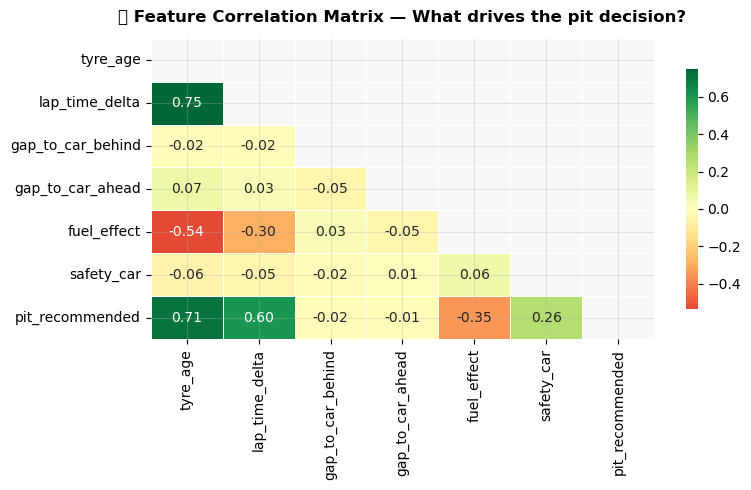

💡 Tyre age and lap_time_delta are the strongest predictors — exactly what a race engineer watches


In [4]:
# Correlation heatmap — what features relate to the pit decision?
fig, ax = plt.subplots(figsize=(8, 5))

numeric_cols = ['tyre_age', 'lap_time_delta', 'gap_to_car_behind',
                'gap_to_car_ahead', 'fuel_effect', 'safety_car', 'pit_recommended']
corr = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('📊 Feature Correlation Matrix — What drives the pit decision?',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Tyre age and lap_time_delta are the strongest predictors — exactly what a race engineer watches')

---
## Step 3 — Prepare the Data for ML

Machine learning models need numbers.  
We need to convert our `tyre_compound` text column into numbers — this is called **encoding**.

In [5]:
# Encode tyre compound: soft=2, medium=1, hard=0
le = LabelEncoder()
df['compound_encoded'] = le.fit_transform(df['tyre_compound'])

print('Compound encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# Define features (X) and target (y)
FEATURES = [
    'tyre_age',
    'lap_time_delta',
    'compound_encoded',
    'gap_to_car_behind',
    'gap_to_car_ahead',
    'fuel_effect',
    'safety_car'
]

X = df[FEATURES]
y = df['pit_recommended']

# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\n✅ Training set: {X_train.shape[0]} laps')
print(f'✅ Test set:     {X_test.shape[0]} laps')
print(f'\nFeatures used by the model:')
for f in FEATURES:
    print(f'  • {f}')

Compound encoding: {'hard': 0, 'medium': 1, 'soft': 2}

✅ Training set: 708 laps
✅ Test set:     177 laps

Features used by the model:
  • tyre_age
  • lap_time_delta
  • compound_encoded
  • gap_to_car_behind
  • gap_to_car_ahead
  • fuel_effect
  • safety_car


---
## Step 4 — Train the Model

We're using a **Random Forest Classifier** — a great beginner model because:
- ✅ Works well out of the box with minimal tuning
- ✅ Handles mixed data types (numbers + categories)
- ✅ Gives us **feature importance** — we can see *why* it made a decision
- ✅ Very explainable to non-technical stakeholders (like race strategists!)

> 💡 A Random Forest trains many small decision trees and combines their votes.  
> Like asking 100 race engineers and taking the majority opinion.

In [6]:
# Train the model
model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    max_depth=8,         # Keep trees interpretable
    random_state=42,
    class_weight='balanced'  # Handle class imbalance
)

print('🏎️  Training the model...')
model.fit(X_train, y_train)
print('✅ Model trained!')

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'\n🎯 Test Accuracy: {accuracy*100:.1f}%')
print()
print(classification_report(y_test, y_pred, target_names=['Stay Out', 'Pit Recommended']))

🏎️  Training the model...
✅ Model trained!

🎯 Test Accuracy: 88.7%

                 precision    recall  f1-score   support

       Stay Out       0.92      0.91      0.91       118
Pit Recommended       0.82      0.85      0.83        59

       accuracy                           0.89       177
      macro avg       0.87      0.88      0.87       177
   weighted avg       0.89      0.89      0.89       177



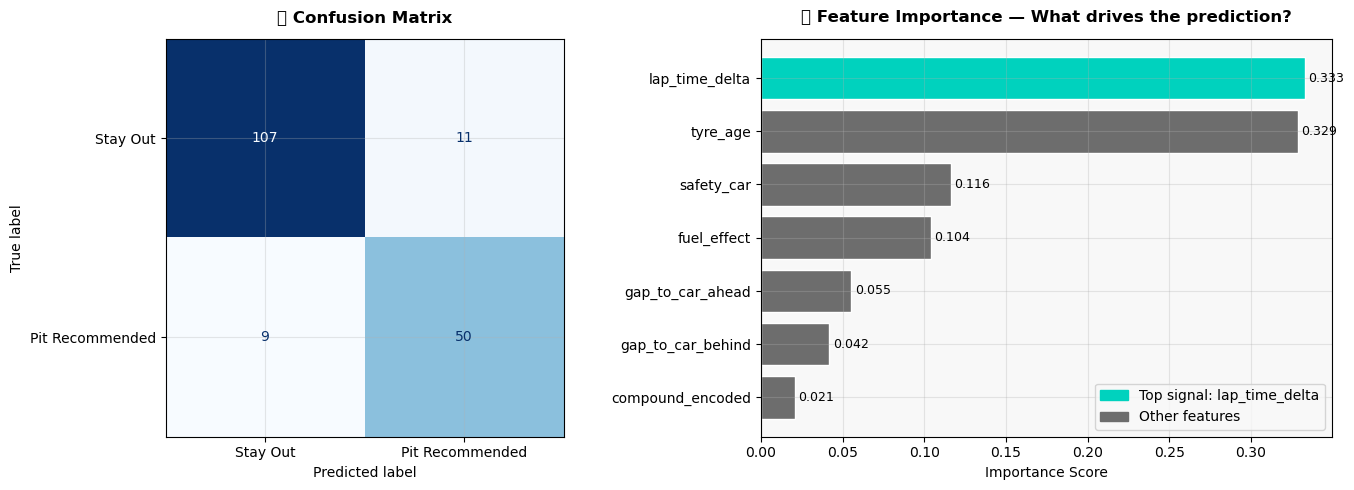

💡 "lap_time_delta" is the most important signal — just as a real race engineer would expect!


In [7]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Stay Out', 'Pit Recommended'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('🔍 Confusion Matrix', fontweight='bold', pad=12)

# Right: Feature importance
importances = pd.Series(model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

colours_bar = [MERC_TEAL if v == importances.max() else F1_SILVER for v in importances.values]
bars = axes[1].barh(importances.index, importances.values,
                    color=colours_bar, edgecolor='white')
axes[1].set_title('⭐ Feature Importance — What drives the prediction?',
                  fontweight='bold', pad=12)
axes[1].set_xlabel('Importance Score')
for bar, val in zip(bars, importances.values):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

# Highlight the top feature
top_feature = importances.idxmax()
teal_patch = mpatches.Patch(color=MERC_TEAL, label=f'Top signal: {top_feature}')
gray_patch  = mpatches.Patch(color=F1_SILVER, label='Other features')
axes[1].legend(handles=[teal_patch, gray_patch], loc='lower right')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💡 "{top_feature}" is the most important signal — just as a real race engineer would expect!')

---
## Step 5 — Live Race Decision 🏁

### The Scenario

> 📻 *"Box, box, box?"* — the question every driver waits for on the radio.

It's **Lap 34** of the race. George Russell is on **medium tyres, lap 19** of that stint.  
His lap times are dropping — **+0.72s slower** than a fresh medium tyre.  
The car behind is **2.8 seconds** back. The car ahead is **4.1 seconds** ahead.  
No safety car. Fuel load is moderate.

**Should Mercedes call George in?**

In [8]:
# Live race scenario
live_scenario = pd.DataFrame([{
    'tyre_age':           19,     # 19 laps on current mediums
    'lap_time_delta':     0.72,   # 0.72s slower than fresh tyre
    'compound_encoded':   1,      # medium = 1
    'gap_to_car_behind':  2.8,    # 2.8s gap behind
    'gap_to_car_ahead':   4.1,    # 4.1s gap ahead
    'fuel_effect':        0.65,   # moderate fuel remaining
    'safety_car':         0       # no safety car
}])

# Get prediction and confidence
prediction   = model.predict(live_scenario)[0]
probabilities = model.predict_proba(live_scenario)[0]
confidence   = probabilities[prediction] * 100

# Display result
print('═' * 55)
print('  🏎️  MERCEDES-AMG PETRONAS F1 — PIT WALL AI')
print('═' * 55)
print(f'  Driver:        George Russell (#63)')
print(f'  Lap:           34')
print(f'  Tyre:          Medium — Age: 19 laps')
print(f'  Lap delta:     +0.72s vs fresh tyre')
print(f'  Gap behind:    2.8s')
print(f'  Gap ahead:     4.1s')
print(f'  Safety car:    No')
print('─' * 55)

if prediction == 1:
    print(f'  📻  RECOMMENDATION:  ✅ BOX THIS LAP')
else:
    print(f'  📻  RECOMMENDATION:  🔴 STAY OUT')

print(f'  Model confidence: {confidence:.1f}%')
print(f'  Stay Out probability:       {probabilities[0]*100:.1f}%')
print(f'  Pit Recommended probability: {probabilities[1]*100:.1f}%')
print('═' * 55)

═══════════════════════════════════════════════════════
  🏎️  MERCEDES-AMG PETRONAS F1 — PIT WALL AI
═══════════════════════════════════════════════════════
  Driver:        George Russell (#63)
  Lap:           34
  Tyre:          Medium — Age: 19 laps
  Lap delta:     +0.72s vs fresh tyre
  Gap behind:    2.8s
  Gap ahead:     4.1s
  Safety car:    No
───────────────────────────────────────────────────────
  📻  RECOMMENDATION:  ✅ BOX THIS LAP
  Model confidence: 93.3%
  Stay Out probability:       6.7%
  Pit Recommended probability: 93.3%
═══════════════════════════════════════════════════════


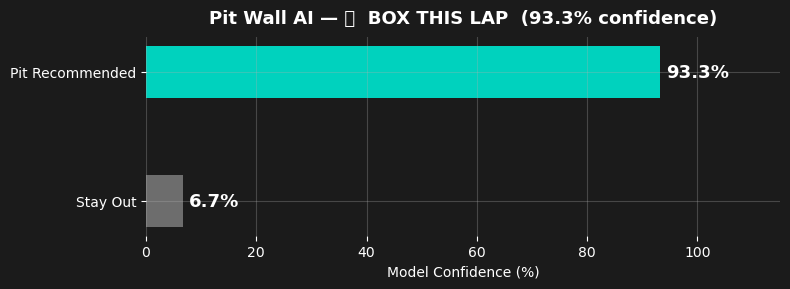

In [9]:
# Visual confidence display
fig, ax = plt.subplots(figsize=(8, 3))
fig.patch.set_facecolor(MERC_DARK)
ax.set_facecolor(MERC_DARK)

labels_bar   = ['Stay Out', 'Pit Recommended']
values_bar   = [probabilities[0] * 100, probabilities[1] * 100]
bar_colours  = [F1_SILVER, MERC_TEAL if prediction == 1 else F1_RED]

bars = ax.barh(labels_bar, values_bar, color=bar_colours,
               edgecolor='none', height=0.4)

for bar, val in zip(bars, values_bar):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', color='white',
            fontsize=13, fontweight='bold')

ax.set_xlim(0, 115)
ax.set_xlabel('Model Confidence (%)', color='white')
ax.tick_params(colors='white')
ax.spines[['top','right','bottom','left']].set_visible(False)

decision_text = '✅  BOX THIS LAP' if prediction == 1 else '🔴  STAY OUT'
ax.set_title(f'Pit Wall AI — {decision_text}  ({confidence:.1f}% confidence)',
             color='white', fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('pit_decision.png', dpi=150, bbox_inches='tight',
            facecolor=MERC_DARK)
plt.show()

---
## Step 6 — Try Your Own Scenario 🎮

Change the values below and re-run the cell.  
Try pushing tyre age to 28, or setting `safety_car = 1` — see what the model says!

In [10]:
# ✏️ EDIT THESE VALUES TO TRY YOUR OWN SCENARIO
# ─────────────────────────────────────────────
MY_SCENARIO = {
    'tyre_age':          25,      # How many laps on current tyres?
    'lap_time_delta':    0.90,    # How many seconds slower than a fresh tyre?
    'compound_encoded':  2,       # 0 = hard, 1 = medium, 2 = soft
    'gap_to_car_behind': 1.2,     # Seconds gap to car behind
    'gap_to_car_ahead':  3.5,     # Seconds gap to car ahead
    'fuel_effect':       0.40,    # Fuel weight effect (lower = less fuel = later laps)
    'safety_car':        0        # 1 = safety car out, 0 = green flag racing
}
# ─────────────────────────────────────────────

scenario_df  = pd.DataFrame([MY_SCENARIO])
pred         = model.predict(scenario_df)[0]
proba        = model.predict_proba(scenario_df)[0]
conf         = proba[pred] * 100
compound_map = {0: 'Hard', 1: 'Medium', 2: 'Soft'}

print('═' * 50)
print('  🎮  YOUR SCENARIO')
print('═' * 50)
print(f'  Tyre compound:  {compound_map[MY_SCENARIO["compound_encoded"]]}')
print(f'  Tyre age:       {MY_SCENARIO["tyre_age"]} laps')
print(f'  Lap time delta: +{MY_SCENARIO["lap_time_delta"]}s')
print(f'  Gap behind:     {MY_SCENARIO["gap_to_car_behind"]}s')
print(f'  Safety car:     {"Yes ⚠️" if MY_SCENARIO["safety_car"] else "No"}')
print('─' * 50)

if pred == 1:
    print(f'  📻  BOX THIS LAP  ✅  ({conf:.1f}% confidence)')
else:
    print(f'  📻  STAY OUT  🔴  ({conf:.1f}% confidence)')
print('═' * 50)

══════════════════════════════════════════════════
  🎮  YOUR SCENARIO
══════════════════════════════════════════════════
  Tyre compound:  Soft
  Tyre age:       25 laps
  Lap time delta: +0.9s
  Gap behind:     1.2s
  Safety car:     No
──────────────────────────────────────────────────
  📻  BOX THIS LAP  ✅  (95.6% confidence)
══════════════════════════════════════════════════


---
## Step 7 — How This Maps to Azure ML at Scale ☁️

What we just built in a notebook is the **same conceptual pattern** that Mercedes uses with Azure — at a much larger scale:

| What we did here | What Mercedes does with Azure |
|---|---|
| CSV file with 885 rows | 1.1M data points per second, per car |
| Jupyter notebook | Azure ML pipelines with automated retraining |
| Single Random Forest | Ensemble models + Azure AutoML experimentation |
| `model.predict()` | Real-time Azure ML endpoint deployed via AKS |
| Printed result | Live dashboard on the pit wall strategy screen |
| One race scenario | 24 circuits × 2 cars × full season |

### The Azure ML path from here:

```
1. azureml-sdk / Azure ML Studio
   └── Register dataset in Azure ML datastore

2. Azure ML Experiment
   └── Run this notebook as a training job on a compute cluster
   └── Logs metrics (accuracy, F1 score) automatically

3. Model Registry
   └── Register the trained model with version control

4. Real-time Endpoint (via AKS)
   └── Deploy as REST API
   └── Call from pit wall dashboard: POST /score {tyre_age: 19, ...}

5. Monitoring
   └── Azure ML model monitoring tracks data drift across the season
```

> 💡 **Azure Kubernetes Service (AKS)** is what Mercedes uses to scale this up and down —  
> bursting compute during race weekends, scaling back during testing and off-season.


In [11]:
# Final summary
print('🏁 SESSION RECAP')
print('═' * 50)
print(f'  Dataset:       {len(df)} laps across {df["race_id"].nunique()} races')
print(f'  Features:      {len(FEATURES)}')
print(f'  Model:         Random Forest (100 trees)')
print(f'  Accuracy:      {accuracy*100:.1f}%')
print(f'  Top signal:    {importances.idxmax()}')
print()
print('  What we built = the same pattern Mercedes uses')
print('  with Azure ML — just at race speed and scale.')
print()
print('  🚀 The pit window is open. Go build something fast.')
print('═' * 50)

🏁 SESSION RECAP
══════════════════════════════════════════════════
  Dataset:       885 laps across 20 races
  Features:      7
  Model:         Random Forest (100 trees)
  Accuracy:      88.7%
  Top signal:    lap_time_delta

  What we built = the same pattern Mercedes uses
  with Azure ML — just at race speed and scale.

  🚀 The pit window is open. Go build something fast.
══════════════════════════════════════════════════


---
## Resources

- 🔗 [Microsoft × Mercedes-AMG PETRONAS F1 Partnership](https://news.microsoft.com/source/2026/01/22/microsoft-and-mercedes-amg-petronas-f1-team-unite-to-drive-innovation-from-factory-to-circuit/)
- 📚 [Azure Machine Learning Documentation](https://learn.microsoft.com/en-us/azure/machine-learning/)
- 🎓 [Microsoft Learn — AI Fundamentals](https://learn.microsoft.com/en-us/training/paths/get-started-with-artificial-intelligence-on-azure/)
- 🏎️ [Formula 1 Official Site](https://www.formula1.com)

---
*Built for Global Azure — "Lights Out and Away We Go"*  
*Thank you for attending!* 🏆